# Fig3_attention.ipynb

## Introduction
This notebook processes species attention scores in relation to multiple environmental factors. It includes:
1. Calculating overall attention scores.
2. Sorting and visualizing the environmental factor weights.
3. Investigating forest vs non-forest species distinctions.
4. Assessing relationships between attention scores and average elevation.

In [1]:
# Import necessary libraries and modules.
# The PlotUtlis class, create_folder, mm2inch, and set_mpl_defaults come from the Utils.py script.
# They provide helper functionalities such as figure styling, directory creation, and data manipulation.

from Utils import PlotUtlis, create_folder, mm2inch, set_mpl_defaults, convert_to_env_list_detail, reorder_df_attention, get_significance_stars
import pandas as pd
import copy
from matplotlib import font_manager as fm
import h5py
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

# Set default plotting parameters (e.g., fonts, axes, etc.)
set_mpl_defaults()

### Translate species name to Chinese

In [2]:
def get_chinese_sciname(target_name):
    change_names = {
    'Anas_zonorhyncha': 'Anas_poecilorhyncha', 
    'Cyanoderma_ruficeps': 'Stachyridopsis_ruficeps', 
    'Erythrogenys_erythrocnemis': 'Pomatorhinus_erythrocnemis', 
    'Ictinaetus_malaiensis': 'Ictinaetus_malayensis', 
    'Lewinia_striata': 'Gallirallus_striatus', 
    'Machlolophus_holsti': 'Parus_holsti', 
    'Pterorhinus_poecilorhynchus': 'Garrulax_poecilorhynchus', 
    'Pterorhinus_ruficeps': 'Garrulax_ruficeps', 
    'Schoeniparus_brunneus': 'Alcippe_brunnea', 
    'Sittiparus_castaneoventris': 'Poecile_varius', 
    'Synoicus_chinensis': 'Coturnix_chinensis', 
    'Taenioptynx_brodiei': 'Glaucidium_brodiei', 
    'Tarsiger_formosanus': 'Tarsiger_indicus', 
    'Turdus_niveiceps': 'Turdus_poliocephalus', 
    'Zapornia_fusca': 'Porzana_fusca'
    }
    df_name = pd.read_csv('../2023臺灣鳥類名錄-20230419.csv')
    for (new_name, orig_name) in change_names.items():
        if target_name == orig_name:
            target_name = new_name
            
    df_target = df_name[df_name['學名'] == target_name.replace('_', ' ')]
    return df_target['中文名'].values[0]

In [3]:
# Define run_id and exp_id for referencing the appropriate directories and configurations.
run_id = 'f6a76e871ce645dfacd7701ed5ad564f'
exp_id = '514555744033707035'

In [4]:
# Instantiate PlotUtlis with the given run_id and exp_id.
# This object offers various methods for data loading and path management.
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

In [5]:
# Create output folder paths for storing attention-related plots.
create_folder(PU.plot_path_attention)

### Calculate attention score of each species 

In [6]:
# Create a DataFrame of attention scores for each species, using PlotUtlis method.
# This averages the attention across all relevant dates. The method internally handles reading the data from h5 files.

df_attention = PU.create_attention_df()
df_attention.to_csv(PU.df_attention_path)

### Sort the attention weights for each environmental factor

In [7]:
# Reads the attention DataFrame from a saved CSV file. Then sums across species for each factor.
# Sort factors by total attention.

df_attention = pd.read_csv(PU.df_attention_path, index_col = 0)
df_attention_sumsort = df_attention.sum().sort_values()
df_attention_sumsort.index = convert_to_env_list_detail(df_attention_sumsort.index)
df_attention_sumsort

Relative humidity      20.566867
LandcoverPC3           20.590717
Temperature            21.031595
Shortwave radiation    21.146239
LandcoverPC2           21.235442
EVI                    21.281651
Precipitation          21.342029
Wind speed             24.184026
LandcoverPC1           25.527025
LandcoverPC4           26.713086
Cloud area fraction    28.381322
dtype: float64

### BAR PLOT

In [8]:
# Reorder the attention DataFrame so it can be plotted in a stacked bar chart.
df_attention_order = reorder_df_attention(df_attention)
# species_list_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
species_list_exclude = []
df_attention_order = df_attention_order[~df_attention_order.index.isin([sp.replace('_', ' ') for sp in species_list_exclude])]

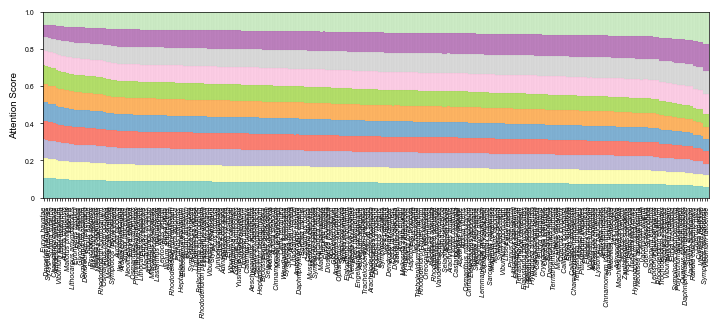

In [9]:
# Create a custom color map for the stacked bar plot.
# Plot stacked bars to visualize the contribution of each environmental factor per species.

custom_colors = [
    "#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3", 
    "#fdb462", "#b3de69", "#fccde5", "#d9d9d9", "#bc80bd", 
    "#ccebc5", "#ffed6f"
]
env_names =  list(df_attention_order.columns)
custom_cmap = {name: color for name, color in zip(env_names, custom_colors)}


colors_for_cols = [custom_cmap[c] for c in df_attention_order.columns]
fig, ax = plt.subplots(figsize = mm2inch(180, 75), 
                       gridspec_kw = {'left': 0.05, 'right': 0.99, 'bottom': 0.35, 'top': 0.98})

df_attention_order.plot(kind="bar", stacked=True, color=colors_for_cols, width=1, 
                      ax=ax, edgecolor="black", linewidth=0.01, legend = None)

ax.set_ylabel("Attention Score")
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(labels = [0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks(np.arange(len(df_attention_order.index)))
ax.set_xticklabels(df_attention_order.index, rotation=90, ha='center', va='top', fontstyle='italic')
ax.set_ylim(0, 1)
plt.margins(x=0)
ax.set_xlim(-0.5, len(df_attention_order.index) - 0.5)

plot_output = os.path.join(PU.plot_path_attention, 'attention_barplot.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

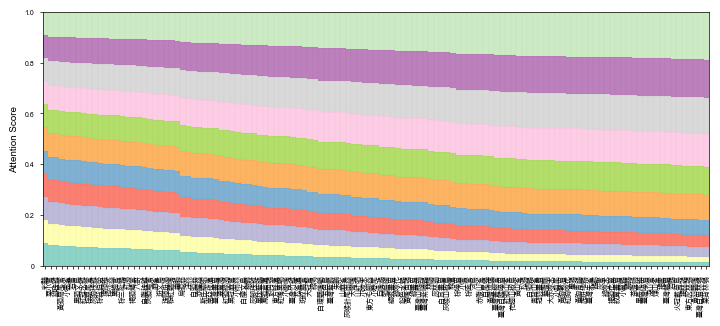

In [10]:
from matplotlib import font_manager as fm

font_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
font_prop = fm.FontProperties(fname=font_path)

custom_colors = [
    "#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3", 
    "#fdb462", "#b3de69", "#fccde5", "#d9d9d9", "#bc80bd", 
    "#ccebc5", "#ffed6f"
]
env_names =  list(df_attention_order.columns)
custom_cmap = {name: color for name, color in zip(env_names, custom_colors)}


colors_for_cols = [custom_cmap[c] for c in df_attention_order.columns]
fig, ax = plt.subplots(figsize = mm2inch(180, 80), constrained_layout = True)

df_attention_order.plot(kind="bar", stacked=True, color=colors_for_cols, width=1, 
                      ax=ax, edgecolor="black", linewidth=0.01, legend = None)

ax.set_ylabel("Attention Score")
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(labels = [0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticks(np.arange(len(df_attention_order.index)))
ax.set_xticklabels([get_chinese_sciname(sp.replace(' ', '_')) for sp in df_attention_order.index], ha='center', va='top', fontstyle='italic', fontproperties = font_prop, rotation = 90)
ax.set_ylim(0, 1)
plt.margins(x=0)
ax.set_xlim(-0.5, len(df_attention_order.index) - 0.5)

plot_output = os.path.join(PU.plot_path_attention, 'attention_barplot_chinese.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Forest habitat

In [30]:
# Retrieve habitat designations (forest vs non-forest) for each species in the order of df_attention_order.
habitat = PU.get_species_habitat(df_attention_order)

In [31]:
import pandas as pd
import numpy as np

# 1) Convert the habitat list into a Series aligned with df_attention_order
hab_s = pd.Series(habitat, index=df_attention_order.index, name='Habitat')

# 2) Sum of each habitat — equal to the number of species in that habitat 
#    (since each species contributes one row with total sum = 1)
attn_sum_by_hab = df_attention_order.groupby(hab_s).sum().sort_index()

# 3) Mean of each habitat — equivalent to dividing the summed values by 
#    the number of species in each habitat (same as .mean())
attn_mean_by_hab = df_attention_order.groupby(hab_s).mean().sort_index()

# 4) Proportion within each habitat — normalize each habitat’s total so 
#    that the sum across environmental variables equals 1
#    (row-normalization of the habitat-level sums)
attn_prop_by_hab = attn_sum_by_hab.div(attn_sum_by_hab.sum(axis=1), axis=0)

# 5) Alignment checks (recommended sanity checks)
assert len(habitat) == len(df_attention_order)
assert np.allclose(attn_sum_by_hab.sum(axis=1).values, hab_s.value_counts().sort_index().values)

# 6) Extract the top three most important environmental variables 
#    (by proportion) for each habitat
top3_each_hab = (
    attn_prop_by_hab
      .stack()                                # → Long-format index (Habitat, Env)
      .groupby(level=0)                       # Group by habitat
      .apply(lambda s: s.sort_values(ascending=False).head(3))
)


In [32]:
import pandas as pd
import numpy as np

# Alignment check (optional but recommended)
assert len(habitat) == len(df_attention_order)

# Convert habitat list into a Series aligned with species index
hab_s = pd.Series(habitat, index=df_attention_order.index, name='Habitat')

# Count the number of species in each habitat
n_by_hab = hab_s.value_counts().sort_index()
print(n_by_hab)

# Save to CSV file (optional)
n_by_hab.rename_axis('Habitat').to_frame('n_species').to_csv('n_species_by_habitat.csv')


Habitat
Habitat_DrylandFarming            1
Habitat_Forest                   87
Habitat_ForestEdge               11
Habitat_FreshwaterLakesPools      1
Habitat_MiddleUpperOfStream       5
Habitat_PermanentInlandDeltas     4
Habitat_RockyShoreline            1
Habitat_Shortgrass                5
Habitat_Shrubland                 4
Habitat_Tallgrass                 2
Name: count, dtype: int64


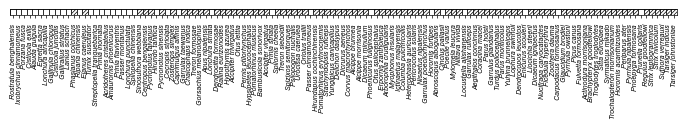

In [33]:
# Create a figure that visually marks forest vs non-forest species using hatching.
# Each rectangle in the figure is hatched or not based on the habitat.

forest_hatch = '/////////'
non_forest_hatch = ''
fig, ax = plt.subplots(figsize = mm2inch(180, 30), gridspec_kw = {'left': 0.05, 'right': 0.99, 'bottom': 0.93, 'top': 0.98})

for i, h in enumerate(habitat):
    if h == 'Habitat_Forest':
        rect = mpatches.Rectangle(
            (i, 0), 1, 1,      
            facecolor='white', 
            edgecolor='black', 
            hatch=forest_hatch,
            linewidth = 0.5
        )
    else:
        rect = mpatches.Rectangle(
            (i, 0), 1, 1,
            facecolor='white',
            edgecolor='black',
            hatch=non_forest_hatch,
            linewidth = 0.5
        )
    ax.add_patch(rect)

ax.set_xlim(0, len(habitat))
ax.set_ylim(0, 1)
ax.set_xticks(range(len(habitat)))
ax.set_xticks(np.arange(len(df_attention_order.index))+0.5)
ax.set_xticklabels(df_attention_order.index, rotation=90, ha='center', va='top', fontstyle='italic')
ax.set_yticks([])

plot_output = os.path.join(PU.plot_path_attention, 'forest.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Attention score by environmental factors

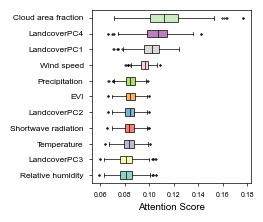

In [10]:
# Draw boxplots for each environmental factor across all species.
# The custom color list is used to distinguish different factors.
fig, ax = plt.subplots(figsize = mm2inch(65, 55), gridspec_kw = {'left': 0.33, 'right': 0.95, 'bottom': 0.15, 'top': 0.95})
box = ax.boxplot(df_attention_order.values, vert = False, patch_artist = True, tick_labels = df_attention_order.columns,
                 medianprops = dict(color = 'black'),
                )

for patch, label in zip(box['boxes'], df_attention_order.columns):
    patch.set_facecolor(custom_cmap[label])
    patch.set_edgecolor('black')

ax.set_xlabel("Attention Score")
ax.set_yticklabels(list(df_attention_order.columns), fontsize = 6)

plot_output = os.path.join(PU.plot_path_attention, 'attention_boxplot_by_env.pdf')

plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Correlation of "hurs" with average elevation

In [35]:
# Load a table of average elevation for each species.
avg_elevation = pd.read_csv(PU.avg_elev_path)

0.9686966535699767 7.381089204088849e-74


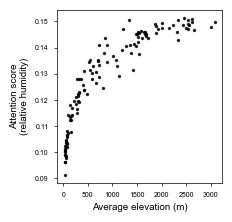

In [153]:
# Scatter plot of average elevation vs. the attention score for "Cloud area fraction".
# Spearman correlation is calculated.

fig, ax = plt.subplots(figsize=mm2inch(60, 55), gridspec_kw = {'left': 0.25, 'right': 0.95, 'bottom': 0.15, 'top': 0.95})
ax.scatter(x = [avg_elevation.AverageElevation[avg_elevation.Species == sp.replace(' ', '_')].tolist()[0] for sp in df_attention_order.index],
           y = df_attention_order['Relative humidity'], 
           c = 'black', 
           alpha = 0.8, 
           s = 2)
ax.set_xlabel('Average elevation (m)')
ax.set_ylabel('Attention score\n(relative humidity)')
rho_cltelev, p_cltelev = spearmanr([avg_elevation.AverageElevation[avg_elevation.Species == sp.replace(' ', '_')].tolist()[0] for sp in df_attention_order.index], 
                                   df_attention_order['Relative humidity'])
print(rho_cltelev, p_cltelev)

plot_output = os.path.join(PU.plot_path_attention, 'atthurs_elev.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Boxplot: Forest vs Non-forest

LandcoverPC3: 7.058842683694505 1.2085411999876755e-10
LandcoverPC1: 7.671543243007108 5.162794977920167e-12


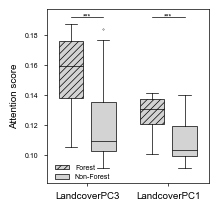

In [160]:
# Extract attention scores for forest and non-forest species for two predictors
forest_pc3 = df_attention_order['LandcoverPC3'][np.array(habitat) == 'Habitat_Forest'].dropna()
nonforest_pc3 = df_attention_order['LandcoverPC3'][np.array(habitat) != 'Habitat_Forest'].dropna()

forest_pc1 = df_attention_order['LandcoverPC1'][np.array(habitat) == 'Habitat_Forest'].dropna()
nonforest_pc1 = df_attention_order['LandcoverPC1'][np.array(habitat) != 'Habitat_Forest'].dropna()

# Run t-tests and get significance stars
t_pc3, p_pc3 = ttest_ind(forest_pc3, nonforest_pc3)
t_pc1, p_pc1 = ttest_ind(forest_pc1, nonforest_pc1)
stars_pc3 = get_significance_stars(p_pc3)
stars_pc1 = get_significance_stars(p_pc1)

print('LandcoverPC3:', t_pc3, p_pc3)
print('LandcoverPC1:', t_pc1, p_pc1)

# Prepare data lists
data_forest = [forest_pc3, forest_pc1]
data_nonforest = [nonforest_pc3, nonforest_pc1]
x_ticks_labels = ['LandcoverPC3', 'LandcoverPC1']

# Define paired positions for forest and non-forest (offset to left/right)
positions_base = np.array([0, 2])
positions_forest = positions_base - 0.4
positions_nonforest = positions_base + 0.4

# Create figure
fig, ax = plt.subplots(figsize=mm2inch(55, 55),
                       gridspec_kw={'left': 0.20, 'right': 0.95, 'bottom': 0.15, 'top': 0.95})

# Boxplot color setup
def set_box_color(bp, hatch=None):
    for patch in bp['boxes']:
        patch.set_edgecolor('black')
        patch.set_facecolor('lightgrey')
        if hatch:
            patch.set_hatch(hatch)
    for key in ['whiskers', 'caps', 'medians']:
        for item in bp[key]:
            item.set_color('black')

# Draw forest and non-forest boxplots
bp_forest = ax.boxplot(data_forest, positions=positions_forest, sym='.', widths=0.6, patch_artist=True)
bp_nonforest = ax.boxplot(data_nonforest, positions=positions_nonforest, sym='.', widths=0.6, patch_artist=True)

set_box_color(bp_forest, hatch='/////')
set_box_color(bp_nonforest)

# Axis labels and ticks
ax.set_xticks(positions_base)
ax.set_xticklabels(x_ticks_labels, fontsize = 7)
ax.set_ylabel('Attention score')

# Set y-axis range based on all values
all_vals = np.concatenate([forest_pc3, nonforest_pc3, forest_pc1, nonforest_pc1])
ymin = np.min(all_vals) - 0.1 * (np.max(all_vals) - np.min(all_vals))
ymax = np.max(all_vals) + 0.1 * (np.max(all_vals) - np.min(all_vals))
ax.set_ylim(ymin, ymax)
ax.set_xlim(-1, 3)
ax.grid(False)

# Add significance stars above each pair of boxes
pairs_info = [
    (positions_forest[0], positions_nonforest[0], stars_pc3,
     max(np.max(forest_pc3), np.max(nonforest_pc3), np.max(forest_pc1), np.max(nonforest_pc1))),
    (positions_forest[1], positions_nonforest[1], stars_pc1,
     max(np.max(forest_pc3), np.max(nonforest_pc3), np.max(forest_pc1), np.max(nonforest_pc1))),
]

for pf, pn, star, y_pair_max in pairs_info:
    x_center = (pf + pn) / 2
    y_text = y_pair_max + 0.03 * (ymax - ymin)
    ax.text(x_center, y_text, star, ha='center', va='bottom', color='black')
    y_line = y_text + 0.001    # draw a thin horizontal line under the star
    ax.plot([pf, pn], [y_line, y_line], color='black', linewidth=0.5)

# Add legend (Forest = hatched; Non-Forest = plain)
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='lightgrey', edgecolor='black', hatch='/////', label='Forest', linewidth=0.5),
    Patch(facecolor='lightgrey', edgecolor='black', label='Non-Forest', linewidth=0.5)
]
ax.legend(handles=legend_handles, loc=(0.038,0))

# Save figure
plot_output = os.path.join(PU.plot_path_attention, 'forest_nonforest_landcoverPC1_PC3_combined.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

In [41]:
PU.coocc_counts[PU.coocc_counts.counts != 0]

,sp1,sp2,counts
0,Abroscopus_albogularis,Acanthis_flammea,3
1,Abroscopus_albogularis,Accipiter_badius,12
2,Abroscopus_albogularis,Accipiter_gentilis,130
3,Abroscopus_albogularis,Accipiter_gularis,219
4,Abroscopus_albogularis,Accipiter_nisus,182
...,...,...,...
107792,Zosterops_erythropleurus,Zosterops_meyeni,2
107793,Zosterops_erythropleurus,Zosterops_simplex,52
107794,Zosterops_japonicus,Zosterops_meyeni,23
107795,Zosterops_japonicus,Zosterops_simplex,46557


### Corelation between environmental factor value and attention score (沒用到)

In [100]:
env_value_all = {}
for i, env in enumerate(PU.env_list_detail):
    env_folder = f'./workspace/raster_data/env_aligned_timespan_avg/{PU.env_list[i]}'
    files = os.listdir(env_folder)
    env_value = []
    for file in files:
        with rasterio.open(os.path.join(env_folder, file), 'r') as f:
            img = f.read(1)
        img = img[img != -9999]
        env_value.append(img)
    env_values = np.concatenate(env_value)
    if PU.env_list[i] not in PU.DeepSDM_conf.training_conf['non_normalize_env_list']:
        env_values = (env_values - PU.env_info['info'][PU.env_list[i]]['mean'])/PU.env_info['info'][PU.env_list[i]]['sd']
    env_value_all[env] = env_values
    

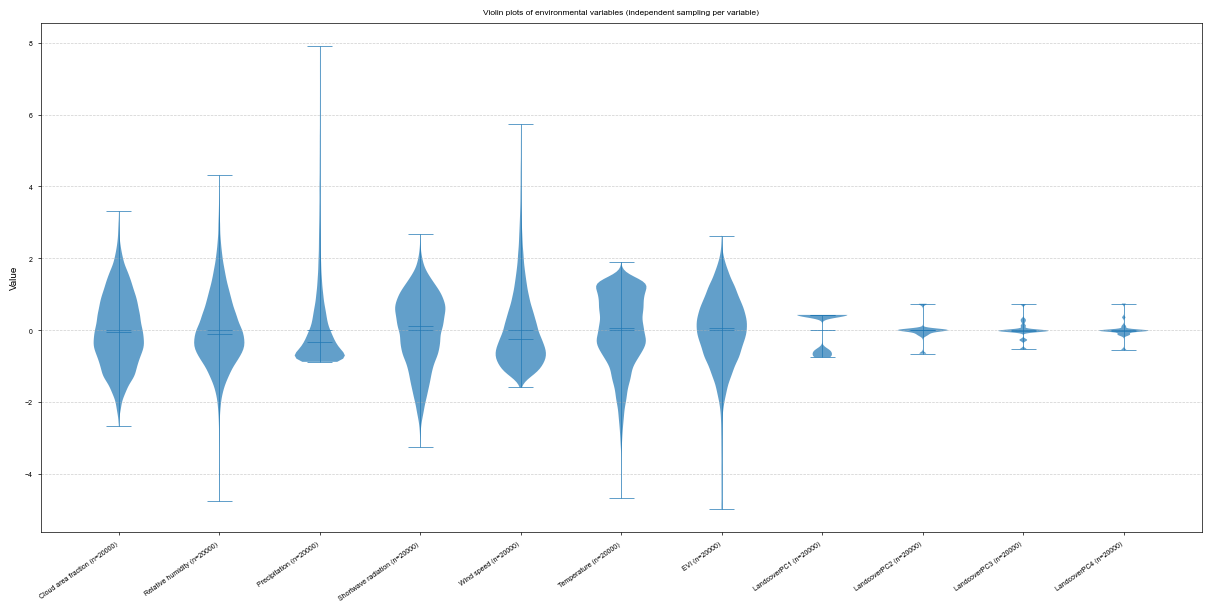

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# -------- 參數 --------
sample_size = 20000                 # 每個變數最多抽樣數量，可依記憶體調整
rng = np.random.default_rng(42)     # 固定亂數種子（可改/移除）
order = PU.env_list_detail
# 只保留實際存在的鍵；若沒有指定順序，就直接用 dict 的鍵順序
order = [k for k in order if k in env_value_all] or list(env_value_all.keys())

def clean_and_sample(arr, nmax, rng):
    a = np.asarray(arr)
    a = a[np.isfinite(a)]           # 去除 NaN/Inf
    if a.size == 0:
        return a
    n = min(nmax, a.size)
    idx_local = rng.choice(a.size, size=n, replace=False)  # 各變數各抽各的
    return a[idx_local]

# -------- 準備資料（各自獨立抽樣）--------
data, labels = [], []
for k in order:
    sampled = clean_and_sample(env_value_all[k], sample_size, rng)
    if sampled.size > 0:
        data.append(sampled)
        labels.append(f"{k} (n={sampled.size})")

# -------- 作圖（純 matplotlib）--------
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

parts = ax.violinplot(
    dataset=data, 
    showmeans=True, 
    showmedians=True, 
    showextrema=True
)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_title("Violin plots of environmental variables (independent sampling per variable)")
ax.set_ylabel("Value")

# 小提琴透明度微調（不指定顏色，照預設）
for pc in parts['bodies']:
    pc.set_alpha(0.7)
ax.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

plt.show()


Spearman correlation between IQR and mean attention:
ρ = -0.137, p = 6.886e-01


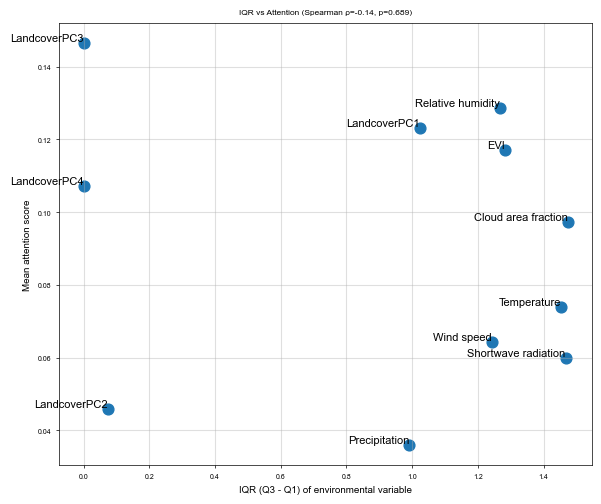

,Q1,Q3,IQR,Mean_attention,logIQR
Cloud area fraction,-0.750343,0.723099,1.473442,0.097296,0.168333
Relative humidity,-0.665872,0.601172,1.267044,0.128723,0.102792
Precipitation,-0.680690,0.310717,0.991407,0.035920,-0.003748
Shortwave radiation,-0.698884,0.767955,1.466839,0.059773,0.166382
Wind speed,-0.737138,0.505581,1.242719,0.064317,0.094373
Temperature,-0.621879,0.831016,1.452895,0.074011,0.162234
EVI,-0.594349,0.688391,1.282740,0.117059,0.108139
LandcoverPC1,-0.594043,0.429250,1.023293,0.123196,0.010000
LandcoverPC2,-0.065891,0.008600,0.074490,0.045809,-1.127899
LandcoverPC3,-0.013040,-0.013040,0.000000,0.146608,-8.000000


In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# === 1. 計算每個環境因子的 IQR ===
records = []
for k, arr in env_value_all.items():
    arr = np.asarray(arr)
    arr = arr[np.isfinite(arr)]  # 去除 NaN / Inf
    if arr.size == 0:
        continue
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    records.append({"Variable": k, "Q1": q1, "Q3": q3, "IQR": iqr})

df_iqr = pd.DataFrame(records).set_index("Variable")

# === 2. 計算 attention score 的平均值 ===
# 假設 df_attention_order 的欄位名稱與 env_value_all 的 key 對應（例如 Precipitation, LandcoverPC1 ...）
df_attention_mean = df_attention_order.mean(axis=0).to_frame("Mean_attention")

# === 3. 合併兩者 ===
df_compare = pd.concat([df_iqr, df_attention_mean], axis=1, join="inner").dropna()
df_compare["logIQR"] = np.log10(df_compare["IQR"] + 1e-8)  # 為了看趨勢可取 log

# === 4. 計算相關係數 ===
rho, pval = spearmanr(df_compare["IQR"], df_compare["Mean_attention"])
print("Spearman correlation between IQR and mean attention:")
print(f"ρ = {rho:.3f}, p = {pval:.3e}")

# === 5. 畫圖 ===
plt.figure(figsize=(6, 5))
plt.scatter(df_compare["IQR"], df_compare["Mean_attention"], s=60)
for name, row in df_compare.iterrows():
    plt.text(row["IQR"], row["Mean_attention"], name, fontsize=8, ha="right", va="bottom")

plt.xlabel("IQR (Q3 - Q1) of environmental variable")
plt.ylabel("Mean attention score")
plt.title(f"IQR vs Attention (Spearman ρ={rho:.2f}, p={pval:.3g})")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

df_compare


### Check if nest structures are related to attention scores of RELATIVE HUMIDITY (沒用到)

In [48]:
def get_species_nest_structure(df_attention_order):
    """
    Retrieve nest-related information from the trait dataset for each species
    and map them to a final list for plotting/analysis.
    """
    taxon_df = pd.read_csv(PU.traitdataset_taxon_path, delimiter='\t')
    measurement_df = pd.read_csv(PU.traitdataset_mesurement_path, delimiter='\t')
    nest_related_df = measurement_df[
        measurement_df['measurementType'].str.contains('Neststructure', na=False, case=False)
    ]
    merged_nest_df = nest_related_df.merge(taxon_df, left_on='id', right_on='taxonID', how='left')
    merged_nest_df['measurementValue'] = merged_nest_df['measurementValue'].astype(float)
    best_nest = merged_nest_df.loc[merged_nest_df.groupby('taxonID')['measurementValue'].idxmax()]
    species_nest_df = best_nest[['scientificName', 'measurementType']].copy()

    name_to_change = {
        'Porzana fusca': 'Zapornia fusca',
        'Gallirallus striatus': 'Lewinia striata',
        'Stachyridopsis ruficeps': 'Cyanoderma ruficeps',
        'Pomatorhinus erythrocnemis': 'Erythrogenys erythrocnemis',
        'Alcippe brunnea': 'Schoeniparus brunneus',
        'Ictinaetus malayensis': 'Ictinaetus malaiensis',
        'Poecile varius': 'Sittiparus castaneoventris',
        'Parus holsti': 'Machlolophus holsti',
        'Turdus poliocephalus': 'Turdus niveiceps',
        'Garrulax poecilorhynchus': 'Pterorhinus poecilorhynchus',
        'Garrulax ruficeps': 'Pterorhinus ruficeps',
        'Glaucidium brodiei': 'Taenioptynx brodiei',
        'Tarsiger indicus': 'Tarsiger formosanus'
    }

    df_attention_sp_name = list(df_attention_order.index)
    for i, name in enumerate(df_attention_sp_name):
        if name in name_to_change:
            df_attention_sp_name[i] = name_to_change[name]
    nest = []
    for sp in df_attention_sp_name:
        if sp not in species_nest_df.scientificName.tolist():
            nest.append(None)
        else:
            nest.append(species_nest_df.measurementType[species_nest_df.scientificName == sp].values.tolist()[0])

    return nest
nest = get_species_nest_structure(df_attention_order)

In [49]:
open_value = []
closed_value = []
for i, n in enumerate(np.array(nest)):
    if n in ['Neststructure_Scrape', 'Neststructure_Platform', 'Neststructure_Cup']:
        open_value.append(df_attention_order['Relative humidity'].iloc[i])
    else:
        closed_value.append(df_attention_order['Relative humidity'].iloc[i])

In [50]:
ttest_ind(open_value, closed_value)

TtestResult(statistic=-1.2522398871858729, pvalue=0.21293799726467322, df=119.0)